# Need to Do

In [10]:
import geopandas as gpd
from gerrychain import Graph, Partition, updaters
from gerrychain.updaters import Tally, cut_edges
from gerrychain.proposals import recom
from gerrychain.constraints import within_percent_of_ideal_population
from gerrychain.optimization import SingleMetricOptimizer
from functools import partial
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
pa_precincts = gpd.read_file("../data/cleaned/pa_cleaned_precincts") 
pa_graph = Graph.from_geodataframe(pa_precincts)


In [3]:
my_updaters = {"population": updaters.Tally("TOTPOP", alias = "population"),
                   "VAP": updaters.Tally("VAP"),
                   "Any Percent Black VAP": updaters.Tally("APBVAP", alias = "Any Percent Black VAP")
              }

initial_partition = Partition(pa_graph, assignment = "SENDIST", updaters = my_updaters)

In [19]:
POP_TOLERANCE = 0.05 
NUM_STEPS = 50000
ideal_pop = sum(initial_partition["population"].values()) / len(initial_partition)

proposal = partial(
    recom,
    pop_col="TOTPOP",
    pop_target=ideal_pop,
    epsilon=POP_TOLERANCE,
    node_repeats=2,
)
chain_constraints = [within_percent_of_ideal_population(initial_partition, POP_TOLERANCE)]

In [20]:
def num_majority_black_districts(partition):
    districts = partition["population"].keys()
    majority_black_districts = 0
    for district in districts:
        district_population = partition["population"].get(district)
        black_population = partition["Any Percent Black VAP"].get(district)
        if(2 * black_population > district_population):
            majority_black_districts += 1
    return majority_black_districts

optimizer = SingleMetricOptimizer(
    proposal=proposal,
    constraints=chain_constraints,
    initial_state=initial_partition,
    optimization_metric=num_majority_black_districts,
    maximize=True
)

In [7]:
burst_size = 20
total_bursts = 100000
total_steps = burst_size * total_bursts
# Short Bursts
min_scores = np.zeros(total_steps)
scores = np.zeros(total_steps)
for i, part in enumerate(optimizer.short_bursts(burst_size, total_bursts, with_progress_bar=True)):
    min_scores[i] = optimizer.best_score
    scores[i] = optimizer.score(part)

 23%|██▎       | 466298/2000000 [2:24:39<10:22:25, 41.07it/s]/opt/anaconda3/lib/python3.13/site-packages/gerrychain/tree.py:704: BipartitionWarning: 
Failed to find a balanced cut after 1000 attempts.
If possible, consider enabling pair reselection within your
MarkovChain proposal method to allow the algorithm to select
a different pair of districts for recombination.
  warnings.warn(
100%|██████████| 2000000/2000000 [9:31:26<00:00, 58.33it/s]    


In [14]:
print(min_scores)
print(scores)
for i in range(200000):
    if min_scores[i] > 2:
        print(i)
        break

[0. 0. 0. ... 3. 3. 3.]
[0. 0. 0. ... 3. 3. 3.]
2491


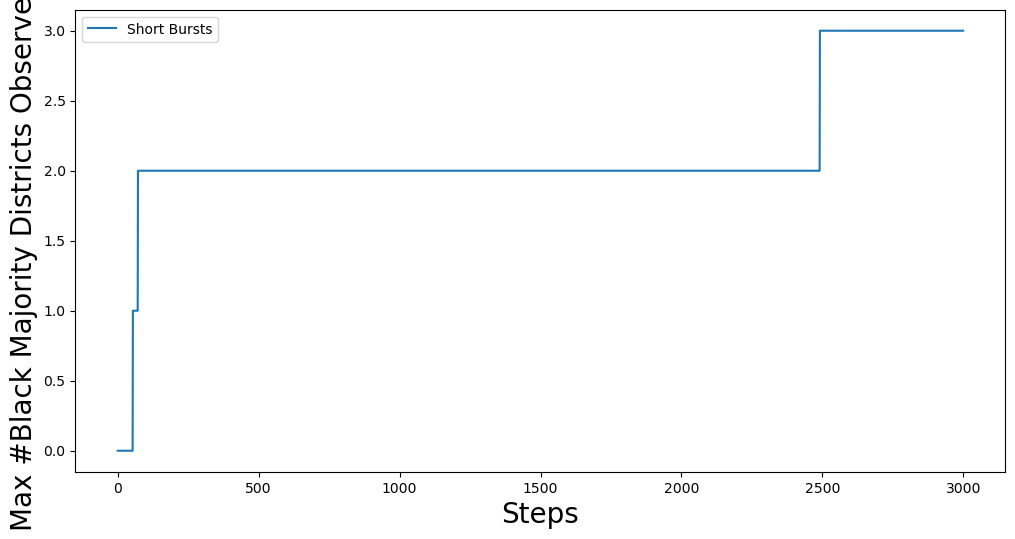

In [16]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(min_scores[:3000], label="Short Bursts")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Max #Black Majority Districts Observered", fontsize=20)
plt.legend()
plt.show()


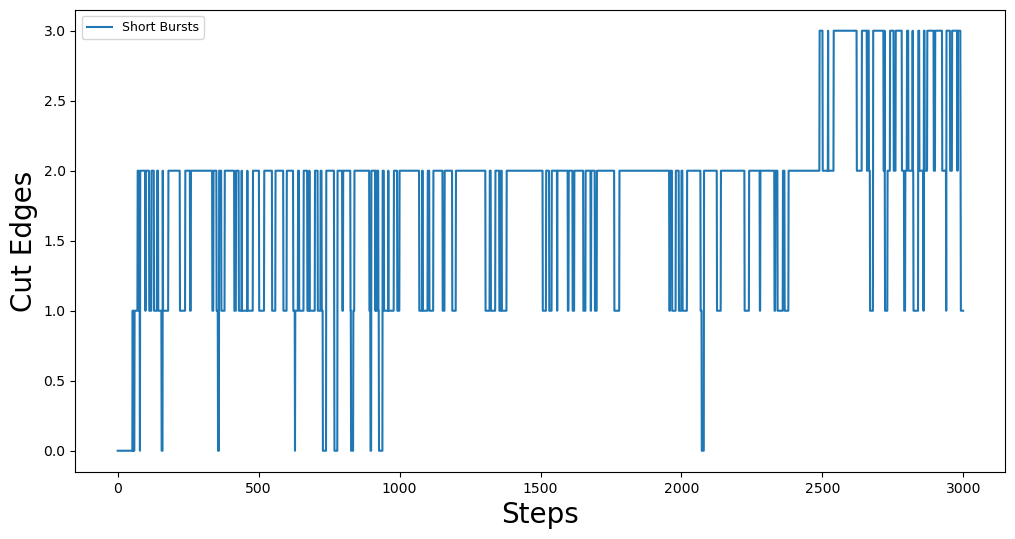

In [18]:
fig, ax = plt.subplots(figsize=(12,6))
plt.plot(scores[:3000], label="Short Bursts")
plt.xlabel("Steps", fontsize=20)
plt.ylabel("Cut Edges", fontsize=20)
plt.legend(fontsize=9)
plt.show()